In [ ]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

# sim_name = f"SunMod_1k"
sim_name = f"SunMod_2k"
sim_folder = f"sim_output/{sim_name}"

fig_folder = f"figures_local/{sim_name}"
Cl_folder = f"Shared/Cls"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)

#! Broken halos: either snapshot info missing or anomalous number densities
exclude_nums = jnp.array([
    20,  # halo with missing/broken snapshot info
    23,  # halo with anomalous number densities (~0s on almost all pixels)
    24,  # anomalous "compactified into 1 cell" DM halo
    25,  # anomalous "compactified into 1 cell" DM halo
])
halo_nums = [x for x in range(1, 31) if x not in exclude_nums]

# Fermi-Dirac distribution assumption
dens_folder = f"sim_output/Dopri5_1k"
# note: total densities are computed for length 50 mass range
pix_dens_FD = jnp.load(f"{dens_folder}/pixel_densities.npy")[tuple(halo_nums),...]
tot_dens_FD = jnp.load(f"{dens_folder}/total_densities.npy")[tuple(halo_nums),...]

# Testing functions

## Momentum transformation function

In [ ]:
@jax.jit
def transform_momenta_to_orig_frame(p_vec, boost_vec, masses=None):
    """
    Transform momentum vectors to original frame using proper Lorentz transformation
    
    Args:
        p_vec: Momentum vectors with shape (..., 3)
        boost_vec: Boost velocity vector (3,)
        masses: Mass values for the second dimension
    """

    # Calculate boost magnitude squared
    boost_mag_squared = jnp.sum(boost_vec**2)
    
    # Check if boost is effectively zero
    # For jax, we can use jax.lax.cond for conditional execution
    def zero_boost_case(_):
        p_vec_mag = jnp.sqrt(jnp.sum(p_vec**2, axis=-1))
        return p_vec_mag, p_vec / p_vec_mag[..., None]
    
    def normal_boost_case(_):
        # Calculate Lorentz factor
        boost_mag = jnp.sqrt(jnp.sum(boost_vec**2))
        Lf = 1/jnp.sqrt(1 - boost_mag**2)  # Lorentz factor
        
        # Calculate momentum magnitude
        p_mag = jnp.sqrt(jnp.sum(p_vec**2, axis=-1))
        
        # Calculate energy
        if masses is not None:
            # Ensure masses is properly dimensioned for this specific p_vec
            # If p_vec has shape (1, 5, 768, 1000, 3) and masses has shape (5,)
            # We want to create energy with shape (1, 5, 768, 1000)
            E = jnp.sqrt(p_mag**2 + jnp.reshape(masses, (1, -1, 1, 1))**2)
        else:
            # Massless case (E = p)
            E = p_mag
        
        # Transform momentum via p⃗' = γ(p⃗ - Ev⃗)
        p_orig_vec = Lf * (p_vec - E[..., None]*boost_vec)
        
        # Get magnitude and unit vectors
        p_orig_mag = jnp.sqrt(jnp.sum(p_orig_vec**2, axis=-1))
        p_orig_unit = p_orig_vec / p_orig_mag[..., None]
        
        return p_orig_mag, p_orig_unit
    
    # Use jax.lax.cond to handle the special case
    return jax.lax.cond(
        boost_mag_squared < 1e-10,  # Threshold for "effectively zero"
        zero_boost_case,
        normal_boost_case,
        operand=None
    )


#region: Boost velocities
# Units used for frame/boost related quantities
Ev_unit = Params.km/Params.s

# Need Earth velocities relative to both:
# 1. Galactic Centre (GC) frame (includes solar system motion)
# (order of 250 km/s)
_, _, Ev_GC = SimUtil.SunEarthGC_frame_coords_posvel(
    2024, Earth_rel_Sun=False)
Ev_GC_boost = Ev_GC*Ev_unit
# 2. Sunlock (SL) frame (i.e. motion of Earth relative to only Sun)
# (order of 30 km/s)
_, _, Ev_SL = SimUtil.SunEarthGC_frame_coords_posvel(
    2024, Earth_rel_Sun=True)
Ev_SL_boost = Ev_SL*Ev_unit

# Load velocities from day simulations (these are in "SunLock" frame)
v_unit = Params.kpc/Params.s
fpath = "sim_output/SunNoG/NoSun_vectors/vectors_day1.npy"
day_v = jnp.load(fpath)[..., 3:][None, ...]*v_unit
# (halos, Npix, p_num, 2, 3)
#endregion


# Momenta before transformation
_, p_pre_vec, *_ = Utils.sim_vels_to_sorted_z0z4_vec(
    day_v/v_unit,  # functions expects kpc/s units 
    nu_m_picks, 
    merge_last_axes=False, 
    args=Params()
)
# print(p_pre_vec.shape)
# (1, masses, Npix, p_num, 3)

# Momenta after transformation
p_aft_mag, p_aft_unit = transform_momenta_to_orig_frame(
    p_vec=p_pre_vec, boost_vec=Ev_SL_boost[0], masses=nu_m_picks)
    # p_vec=p_pre_vec, boost_vec=jnp.zeros(3), masses=nu_m_picks)
# print(p_aft_mag.shape, p_aft_unit.shape)
# (1, masses, Npix, p_num), (1, masses, Npix, p_num, 3)

### Test: invariant mass (fails at high boost above ~0.5c)

In [ ]:
def test_invariant_mass(p_vec, masses, boost_vec):
    """
    Test relativistic invariance for particles with different masses and print results.
    
    Args:
        p_vec: Momentum vectors with shape (1, masses, Npix, p_num, 3)
        masses: Array of mass values corresponding to the masses dimension
        boost_vec: Boost velocity vector (3,)
    """
    print("\n" + "="*80)
    print(f"INVARIANT MASS TEST RESULTS")
    print(f"Boost vector: [{boost_vec[0]:.4f}, {boost_vec[1]:.4f}, {boost_vec[2]:.4f}]")
    print(f"Boost magnitude: {np.linalg.norm(boost_vec):.4f}c")
    print(f"Lorentz factor (γ): {1/np.sqrt(1 - np.sum(boost_vec**2)):.4f}")
    print("="*80)
    print(f"{'Mass':<10} {'Original':<12} {'Transformed':<12} {'Abs Diff':<12} {'Rel Diff':<12} {'Result':<10}")
    print("-"*80)
    
    # Loop through each mass
    for m_idx, mass in enumerate(masses):
        # Extract momentum vectors for this mass
        p_vec_m = p_vec[0, m_idx]  # Shape: (Npix, p_num, 3)
        
        # Calculate momentum magnitudes
        p_mag = jnp.linalg.norm(p_vec_m, axis=-1)  # Shape: (Npix, p_num)
        
        # Calculate energy (E^2 = p^2 + m^2)
        energy = jnp.sqrt(p_mag**2 + mass**2)  # Shape: (Npix, p_num)
        
        # Calculate invariant mass in original frame
        m_squared_orig = energy**2 - p_mag**2  # Should be equal to mass^2

        # Transform to new frame
        p_new_mag, p_new_unit = transform_momenta_to_orig_frame(
            p_vec, boost_vec, masses)  # Add missing dims
        p_new_mag = p_new_mag[0, 0, ...]  # Remove extra dims
        p_new_unit = p_new_unit[0, 0, ...]
        
        # Reconstruct the new momentum vectors
        p_new_vec = p_new_unit * p_new_mag[..., None]
        
        # Calculate energy in new frame (E' = γ(E - v·p))
        Lf = 1/jnp.sqrt(1 - jnp.sum(boost_vec**2))
        p_dot_v = jnp.sum(p_vec_m * boost_vec, axis=-1)
        energy_new = Lf * (energy - p_dot_v)
        
        # Calculate invariant mass in new frame
        m_squared_new = energy_new**2 - jnp.sum(p_new_vec**2, axis=-1)
        
        # Calculate statistics
        mean_orig = jnp.mean(jnp.sqrt(m_squared_orig))
        mean_new = jnp.mean(jnp.sqrt(m_squared_new))
        abs_diff = jnp.abs(mean_new - mean_orig)
        rel_diff = abs_diff / mean_orig
        
        # Determine result
        result = "PASS" if rel_diff < 1e-5 else "FAIL"
        
        # Print results
        print(f"{mass:<10.4e} {mean_orig:<12.6f} {mean_new:<12.6f} {abs_diff:<12.6e} {rel_diff:<12.6e} {result:<10}")
    
    print("="*80)
    print("Note: Test passes if relative difference < 1e-5")
    print("="*80 + "\n")

test_invariant_mass(
    p_vec=p_pre_vec, masses=nu_m_picks, boost_vec=Ev_GC_boost[0]*1000)

### Test: invariant mass, single particle (holds for any boost)

In [ ]:
mass = 1.0*Params.eV  # A significant mass value
p_vec = np.array([3.15, 0.0, 0.0])*Params.T_CNB
boost_vec = Ev_GC_boost[0]*1000

# Calculate energy
p_mag = np.linalg.norm(p_vec)
energy = np.sqrt(p_mag**2 + mass**2)

# Rest mass squared (invariant)
m_squared = energy**2 - p_mag**2
print(f"Original rest mass squared: {m_squared} (should be {mass**2})")

# Lorentz factor
gamma = 1/np.sqrt(1 - np.sum(boost_vec**2))

# Transform energy and momentum
p_dot_v = np.dot(p_vec, boost_vec)
energy_new = gamma * (energy - p_dot_v)

p_new = p_vec + (gamma-1)*(p_dot_v/np.sum(boost_vec**2))*boost_vec - gamma*energy*boost_vec
p_new_mag = np.linalg.norm(p_new)

# New rest mass squared
m_squared_new = energy_new**2 - p_new_mag**2
print(f"New rest mass squared: {m_squared_new}")
print(f"Difference: {m_squared_new - m_squared}")
print(f"Relative difference: {(m_squared_new - m_squared)/m_squared}")

### Test: to and fro transformation (passes for any boost)

In [ ]:
def test_back_transformation(p_vec, boost_vec):
    # Forward transformation
    p_new_mag, p_new_unit = transform_momenta_to_orig_frame(p_vec, boost_vec)
    p_new_vec = p_new_unit * p_new_mag[..., None]
    
    # Backward transformation with negative boost
    p_orig_mag, p_orig_unit = transform_momenta_to_orig_frame(p_new_vec, -boost_vec)
    p_orig_vec = p_orig_unit * p_orig_mag[..., None]
    
    # Compare with original
    print(jnp.unique(jnp.allclose(p_vec, p_orig_vec, rtol=1e-5)))

test_back_transformation(p_vec=p_pre_vec, boost_vec=Ev_GC_boost[0])
test_back_transformation(p_vec=p_pre_vec, boost_vec=Ev_GC_boost[0]*100)
test_back_transformation(p_vec=p_pre_vec, boost_vec=Ev_GC_boost[0]*1000)

## Euler Angles

In [ ]:
def get_direct_rotation(earth_position, cell_position):
    """
    Directly construct a rotation matrix that rotates earth_position to cell_position.
    """
    # Normalize both vectors
    earth_norm = earth_position / jnp.linalg.norm(earth_position)
    cell_norm = cell_position / jnp.linalg.norm(cell_position)
    
    # Calculate the rotation axis
    axis = jnp.cross(earth_norm, cell_norm)
    axis_norm = jnp.linalg.norm(axis)
    
    # Handle parallel or antiparallel vectors
    if axis_norm < 1e-10:
        # If vectors are parallel, no rotation needed
        if jnp.dot(earth_norm, cell_norm) > 0:
            return jnp.eye(3)
        # If vectors are antiparallel, rotate 180° around z-axis
        else:
            return jnp.array([[-1, 0, 0], [0, -1, 0], [0, 0, 1]])
    
    # Normalize the axis
    axis = axis / axis_norm
    
    # Calculate the rotation angle
    cos_angle = jnp.dot(earth_norm, cell_norm)
    sin_angle = axis_norm
    
    # Build rotation matrix using Rodrigues' formula
    K = jnp.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    
    R = jnp.eye(3) + sin_angle * K + (1 - cos_angle) * jnp.matmul(K, K)
    return R


def test_rotation_visualization(
        cell_positions, selected_cell_idx=0, 
        earth_position=jnp.array([8.127, 0., 0.]), azim=-60, elev=30):
    """
    Create a 3D visualization of the coordinate system with the Galactic Center (GC) at origin,
    Earth position, selected cell position, rotated Earth position, and coordinate axes.
    Includes a semi-transparent xy-plane and projection lines.
    
    Args:
        cell_positions: Array of cell positions with shape [halos, 3]
        selected_cell_idx: Index of the cell to visualize
        earth_position: Earth position vector [x, y, z]
        azim: Azimuth angle for 3D plot view
        elev: Elevation angle for 3D plot view
    """
    # Create figure
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Get the selected cell and its properties
    selected_cell = cell_positions[selected_cell_idx]
    
    # Calculate distances
    earth_distance = jnp.linalg.norm(earth_position)
    cell_distance = jnp.linalg.norm(selected_cell)
    
    # Get rotation matrix for this cell
    R = get_direct_rotation(earth_position, selected_cell)
    
    # Apply rotation to Earth position
    # rotated_earth = jnp.matmul(R, earth_position)
    rotated_earth = jnp.einsum('ij,j->i', R, earth_position)
    
    # Scale rotated Earth to match cell distance
    scale_factor = cell_distance / earth_distance
    rotated_earth_scaled = rotated_earth * scale_factor
    
    # Calculate viewing range
    max_range = max(jnp.linalg.norm(earth_position), jnp.linalg.norm(selected_cell)) * 1.5
    
    # Add semi-transparent xy-plane
    xx, yy = np.meshgrid(np.linspace(-max_range, max_range, 10), 
                        np.linspace(-max_range, max_range, 10))
    zz = np.zeros_like(xx)
    
    # Plot the xy-plane with grid lines
    ax.plot_surface(xx, yy, zz, alpha=0.2, color='gray', edgecolor='gray', 
                   linewidth=0.5, shade=False)
    
    # Plot the GC at origin
    ax.scatter([0], [0], [0], color='black', s=100, label='Galactic Center')
    
    # Plot Earth position
    ax.scatter([earth_position[0]], [earth_position[1]], [earth_position[2]], 
               color='blue', s=80, label='Earth')
    
    # Plot the selected cell
    ax.scatter([selected_cell[0]], [selected_cell[1]], [selected_cell[2]], 
               color='purple', s=100, marker='s', label='Selected Cell')
    
    # Plot rotated Earth position
    ax.scatter([rotated_earth[0]], [rotated_earth[1]], [rotated_earth[2]], 
               color='green', s=80, label='Rotated Earth')
    
    # Plot scaled rotated Earth position
    ax.scatter([rotated_earth_scaled[0]], [rotated_earth_scaled[1]], [rotated_earth_scaled[2]], 
               color='lime', s=80, label='Scaled Rotated Earth')
    
    # Add projections to xy-plane
    # Draw projection points
    cell_projection = [selected_cell[0], selected_cell[1], 0]
    earth_projection = [earth_position[0], earth_position[1], 0]
    rot_earth_projection = [rotated_earth[0], rotated_earth[1], 0]
    scaled_rot_earth_projection = [rotated_earth_scaled[0], rotated_earth_scaled[1], 0]
    
    # Plot projection points
    ax.scatter(*cell_projection, color='purple', s=50, alpha=0.5, marker='o')
    ax.scatter(*earth_projection, color='blue', s=40, alpha=0.5, marker='o')
    ax.scatter(*rot_earth_projection, color='green', s=40, alpha=0.5, marker='o')
    ax.scatter(*scaled_rot_earth_projection, color='lime', s=40, alpha=0.5, marker='o')
    
    # Connect points to their projections with dotted lines
    ax.plot([selected_cell[0], cell_projection[0]], 
            [selected_cell[1], cell_projection[1]], 
            [selected_cell[2], cell_projection[2]], 
            color='purple', ls=':', alpha=0.7)
    
    ax.plot([earth_position[0], earth_projection[0]], 
            [earth_position[1], earth_projection[1]], 
            [earth_position[2], earth_projection[2]], 
            color='b', ls=':', alpha=0.7)
    
    ax.plot([rotated_earth[0], rot_earth_projection[0]], 
            [rotated_earth[1], rot_earth_projection[1]], 
            [rotated_earth[2], rot_earth_projection[2]], 
            color='g', ls=':', alpha=0.7)
    
    ax.plot([rotated_earth_scaled[0], scaled_rot_earth_projection[0]], 
            [rotated_earth_scaled[1], scaled_rot_earth_projection[1]], 
            [rotated_earth_scaled[2], scaled_rot_earth_projection[2]], 
            color='lime', ls=':', alpha=0.7)
    
    # Add original coordinate system - make vectors larger
    origin = jnp.zeros(3)
    vector_length = max(earth_distance, cell_distance) * 0.3  # Adjust vector length
    ax.quiver(*origin, vector_length, 0, 0, color='r', label='X axis')
    ax.quiver(*origin, 0, vector_length, 0, color='g', label='Y axis')
    ax.quiver(*origin, 0, 0, vector_length, color='b', label='Z axis')
    
    # Add rotated coordinate system
    ax.quiver(*origin, R[0, 0]*vector_length, R[1, 0]*vector_length, R[2, 0]*vector_length, 
              color='r', linestyle='--', alpha=0.7, label='X\' axis')
    ax.quiver(*origin, R[0, 1]*vector_length, R[1, 1]*vector_length, R[2, 1]*vector_length, 
              color='g', linestyle='--', alpha=0.7, label='Y\' axis')
    ax.quiver(*origin, R[0, 2]*vector_length, R[1, 2]*vector_length, R[2, 2]*vector_length, 
              color='b', linestyle='--', alpha=0.7, label='Z\' axis')
    
    # Connect points with lines from origin
    ax.plot([0, earth_position[0]], [0, earth_position[1]], [0, earth_position[2]], 'b--')
    ax.plot([0, selected_cell[0]], [0, selected_cell[1]], [0, selected_cell[2]], color='purple', ls='--')
    ax.plot([0, rotated_earth[0]], [0, rotated_earth[1]], [0, rotated_earth[2]], 'g--')
    ax.plot([0, rotated_earth_scaled[0]], [0, rotated_earth_scaled[1]], [0, rotated_earth_scaled[2]], color='lime', ls='-')
    
    # Set limits centered on origin
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])
    
    # Set the view angle
    ax.view_init(elev=elev, azim=azim)
    
    # Add labels
    ax.set_xlabel('X (kpc)')
    ax.set_ylabel('Y (kpc)')
    ax.set_zlabel('Z (kpc)')
    ax.set_title(f'Rotation Visualization for Cell {selected_cell_idx}')
    ax.legend(loc='best')
    
    # Calculate metrics for annotation
    direction_alignment = jnp.dot(rotated_earth/jnp.linalg.norm(rotated_earth), 
                                 selected_cell/jnp.linalg.norm(selected_cell))
    distance_to_cell = jnp.linalg.norm(rotated_earth_scaled - selected_cell)
    
    # Get Euler angles for annotation
    zAngle = jnp.arctan2(selected_cell[1], -selected_cell[0])
    yAngle = jnp.arctan2(-selected_cell[2], jnp.linalg.norm(selected_cell[:2]))
    
    # Annotations for clarity
    cell_pos_str = f"Cell: ({selected_cell[0]:.2f}, {selected_cell[1]:.2f}, {selected_cell[2]:.2f})"
    earth_pos_str = f"Earth: ({earth_position[0]:.2f}, {earth_position[1]:.2f}, {earth_position[2]:.2f})"
    rot_earth_str = f"Rotated Earth: ({rotated_earth[0]:.2f}, {rotated_earth[1]:.2f}, {rotated_earth[2]:.2f})"
    scaled_earth_str = f"Scaled Rotated Earth: ({rotated_earth_scaled[0]:.2f}, {rotated_earth_scaled[1]:.2f}, {rotated_earth_scaled[2]:.2f})"
    angle_str = f"Euler Angles: z={np.degrees(zAngle):.2f}°, y={np.degrees(yAngle):.2f}°"
    metrics_str = f"Direction Alignment: {direction_alignment:.6f} | Distance to Cell: {distance_to_cell:.6f} kpc"
    z_height_str = f"Z-heights: Cell: {selected_cell[2]:.2f} kpc, Earth: {earth_position[2]:.2f} kpc, Scaled Rotated Earth: {rotated_earth_scaled[2]:.2f} kpc"
    
    plt.figtext(0.5, 0.01, 
                f"{cell_pos_str} | {earth_pos_str}\n{rot_earth_str} | {scaled_earth_str}\n{angle_str}\n{metrics_str}\n{z_height_str}", 
                ha="center", fontsize=10, bbox={"facecolor":"wheat", "alpha":0.5, "pad":5})
    
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    return fig


# Generate some test cell positions
np.random.seed(42)
num_cells = 10
cell_positions = np.random.uniform(-10, 10, size=(num_cells, 3))

# Add specific test cases
cell_positions[0] = np.array([5.0, 5.0, 5.0])      # pos. 45° octant 
cell_positions[1] = np.array([5.0, 5.0, 0.0])       # xy-plane 45°
cell_positions[2] = np.array([7.0, 3.0, 4.0])       # general position
cell_positions[3] = np.array([-6.0, -2.0, -5.0])    # negative components
cell_positions[4] = np.array([-8.127, 0.0, 0.0])    # antipodal to Earth

# Earth position
earth_position = jnp.array([3.127, 0.0, 0.0])

# Create visualization
fig = test_rotation_visualization(
    cell_positions, 
    selected_cell_idx=0,  # Try different indices to test
    earth_position=earth_position,
    azim=-60,  # Change these to adjust view angle, orig -60
    elev=30  # orig 30
)

# Plotting annual modulations

*(densities computed in separate .py script)*

SunDop5_grav_PSD_Earth_frame_wrtMW_int_pixels
days_dens shape: (31, 5, 5)
day sim is factor [1.00000738 0.9978447  0.99732753 1.03663465 1.13992671] of core sim


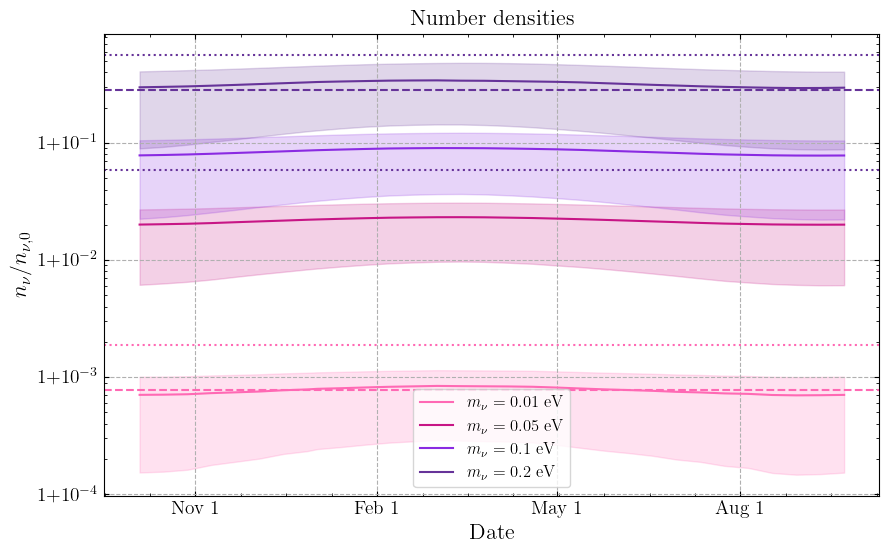

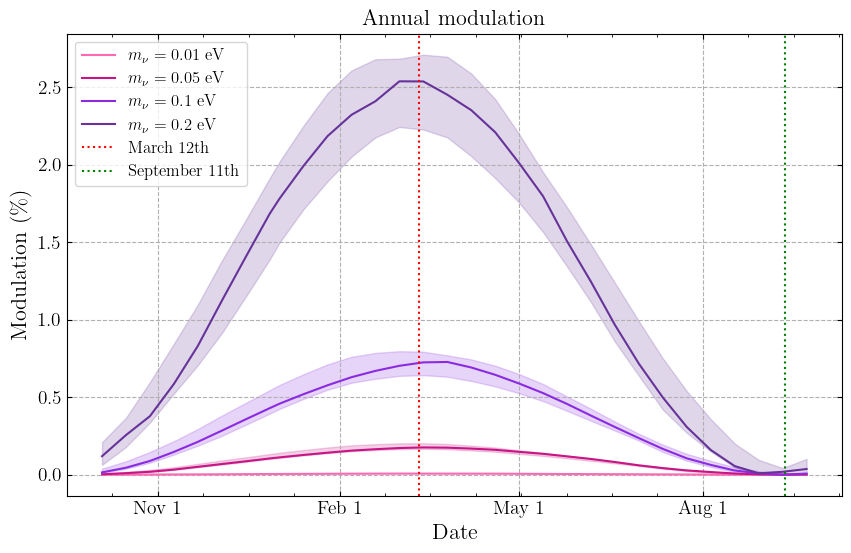

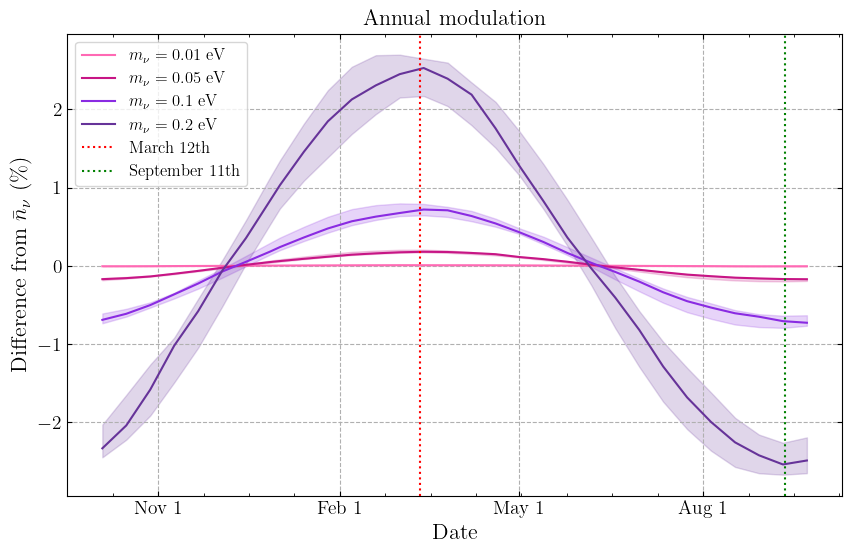

In [ ]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

#! Broken halos: either snapshot info missing or anomalous number densities
exclude_nums = jnp.array([
    20,  # halo with missing/broken snapshot info
    23,  # halo with anomalous number densities (~0s on almost all pixels)
    24,  # anomalous "compactified into 1 cell" DM halo
    25,  # anomalous "compactified into 1 cell" DM halo
])
halo_nums = [x for x in range(1, 31) if x not in exclude_nums]

# Fermi-Dirac distribution assumption
dens_folder = f"sim_output/Dopri5_1k"
# note: total densities are computed for length 50 mass range
pix_dens_FD = jnp.load(f"{dens_folder}/pixel_densities.npy")[tuple(halo_nums),...]
tot_dens_FD = jnp.load(f"{dens_folder}/total_densities.npy")[tuple(halo_nums),...]


### =============== ###
### No Sun versions ###
### =============== ###
#/ done

# No Sun with FD PSD, no boost/rotation, see if no error in data structure
# sim_name = f"SunNoG"
# prefix = "NoG"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# note: log_yaxis=False for mode='densities', otherwise data not visible
# result: nu_dens all flat at or near zero due to no grav and FD PSD

# No Sun with gravPSD, no boost, no rot, see if number densities match
# sim_name = f"SunNoG"
# prefix = "NoG_noBnoR"
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"
# result: nu_dens match [0.999, 0.997, 0.994, 1.023, 1.1097] for nu_m_picks
# note: routine seems good/stable enough for our first 4 masses of interest

# No Sun with gravPSD, with boost, no rot, see effect of MW boost only
# sim_name = f"SunNoG"
# prefix = "NoG"
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"
# result: rel_vel="MW" results in similar shape as bound case in Safdi

# No Sun with gravPSD, with boost, no rot, see effect of CNB boost only
# sim_name = f"SunNoG"
# prefix = "NoG"
# suffix = "_grav_PSD_Earth_frame_wrtCNB_int_pixels"
# result: rel_vel="CNB" results in similar shape as unbound case in Safdi

# For analytical Safdi method, switching relative velocities changes the peak 
# locations and heights (see figures in figures_loca/SunMod_1k).
# Peak locations are similar to our wrtMW and wrtCNB cases, but heights differ.


### =============== ###
### Sun 1k versions ###
### =============== ###

# Sun with FD PSD, 2 boosts, quantify/isolate solar influence only, Dopri5
# sim_name = f"SunMod_1k"
# prefix = "SunDop5"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# note: log_yaxis=False for mode='densities', otherwise data not visible
# result: all curves around 0, i.e. LCDM nu_dens

# Sun with FD PSD, 2 boosts, quantify/isolate solar influence only, Dopri8
# sim_name = f"SunMod_1k"
# prefix = "SunDop8"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# note: log_yaxis=False for mode='densities', otherwise data not visible
# result: no significant deviation from Dopri5 results

# Sun with grav PSD, 2 boosts, Dopri5, quantify difference to FD PSD
sim_name = f"SunMod_1k"
prefix = "SunDop5"
suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"
# result: same shape as FD PSD, but slight spread due to different halos
#/ todo




# sim_name = f"SunMod_2k"


# Sun + DM halo gravity vector
# prefix = "SunLockDM"
#/including DM gravity in daily sims doesn't induce significant changes
#TODO check if using PSD from core sim instead of FD induces visible changes


### =========== ###
### Load & Plot ###
### =========== ###
sim_folder = f"sim_output/{sim_name}"
fig_folder = f"figures_local/{sim_name}"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)

print(f"{prefix}{suffix}")
days_nums = jnp.load(f"{sim_folder}/{prefix}_days_nums{suffix}.npy")
days_dens = jnp.load(f"{sim_folder}/{prefix}_days_dens{suffix}.npy")
print(f"days_dens shape: {days_dens.shape}")
# (days, halos, masses)

if suffix == "_FD_PSD_int_pixels":
    print(f"\nSun clustering factors:")
    print(jnp.mean(days_dens[:,0,:], axis=0)/Params.N0_cm3-1)

halo_num = 5
nu_m_match = jnp.abs(nu_m_range[None, :] - nu_m_picks[:, None]).argmin(axis=-1)
etas_med = np.median(
    tot_dens_FD[:halo_num]/Params.N0_cm3, axis=0)[nu_m_match]
etas_16 = np.percentile(
    tot_dens_FD[:halo_num]/Params.N0_cm3, q=16, axis=0)[nu_m_match]
etas_84 = np.percentile(
    tot_dens_FD[:halo_num]/Params.N0_cm3, q=84, axis=0)[nu_m_match]

etas_stack = jnp.vstack((etas_med,etas_16,etas_84)) - 1

# Compute percentage deviation
etas_med_day_sim = (jnp.median(days_dens[0,...], axis=0)/Params.N0_cm3)
# print((etas_med - etas_med_day_sim)/etas_med*100)
print(f"day sim is factor {etas_med_day_sim/etas_med} of core sim")


SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='densities',
    log_yaxis=True,
    pdf_path=f"{fig_folder}/densities_{prefix}{suffix}",
    etas_tuple=etas_stack
)
SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='modulation',
    mod_method="rel",
    pdf_path=f"{fig_folder}/modulation_rel_{prefix}{suffix}",
)
SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='modulation',
    mod_method="avg",
    pdf_path=f"{fig_folder}/modulation_avg_{prefix}{suffix}",
)

# Deflection angles

In [ ]:
def calculate_deflection_angle(velocity_vectors):
    """
    Calculate the deflection angle between initial and final velocity vectors.
    
    :param velocity_vectors: numpy array of shape (N, 2, 3)
    :return: numpy array of deflection angles in degrees
    """
    z0_vels = velocity_vectors[:, 0, :]
    z4_vels = velocity_vectors[:, -1, :]
    
    # Normalize the vectors
    z0_vels_norm = z0_vels / np.linalg.norm(z0_vels, axis=-1)[:, None]
    z4_vels_norm = z4_vels / np.linalg.norm(z4_vels, axis=-1)[:, None]
    
    # Calculate the dot product
    dot_product = np.sum(z0_vels_norm * z4_vels_norm, axis=-1)
    
    # Clip the dot product to [-1, 1] to avoid numerical errors
    dot_product_clipped = np.clip(dot_product, -1.0, 1.0)
    
    # Calculate the angle in radians and convert to degrees
    angles = np.arccos(dot_product_clipped) * 180 / np.pi
    
    return angles


def analyze_and_plot_deflections(velocity_vectors, bins, exclude_zero):
    """
    Analyze deflection angles and create a plot with median and 1-sigma percentiles.
    The plot range is limited to the min and max found values.
    
    :param velocity_vectors: numpy array of shape (N, 2, 3)
    :param exclude_zero: boolean, if True, exclude zero angles from analysis
    """
    deflection_angles = calculate_deflection_angle(velocity_vectors)
    
    if exclude_zero:
        deflection_angles = deflection_angles[deflection_angles > 0]
        if len(deflection_angles) == 0:
            print("No non-zero deflection angles found. Cannot perform analysis.")
            return

    median = np.median(deflection_angles)
    percentile_16 = np.percentile(deflection_angles, 16)
    percentile_84 = np.percentile(deflection_angles, 84)
    
    min_angle = np.min(deflection_angles)
    max_angle = np.max(deflection_angles)
    
    plt.figure(figsize=(10, 6))
    n, bins, patches = plt.hist(deflection_angles, bins=bins, edgecolor='black')
    plt.axvline(
        median, color='r', linestyle='dashed', linewidth=2, 
        label=f'Median: {median:.2f}°')
    plt.axvline(
        percentile_16, color='g', linestyle='dashed', linewidth=2, 
        label=f'16th percentile: {percentile_16:.2f}°')
    plt.axvline(
        percentile_84, color='g', linestyle='dashed', linewidth=2, 
        label=f'84th percentile: {percentile_84:.2f}°')
    
    plt.xlabel('Deflection Angle (degrees)')
    plt.ylabel('Frequency')
    title = 'Distribution of Deflection Angles'
    if exclude_zero:
        title += ' (Excluding Zero Angles)'
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Set x-axis limits to min and max found values
    plt.xlim(min_angle, max_angle)
    
    # Adjust y-axis to show full height of the tallest bar
    plt.ylim(0, max(n) * 1.1)
    
    
    print(f"Median deflection angle: {median:.2f}°")
    print(f"1-sigma range: {percentile_16:.2f}° - {percentile_84:.2f}°")
    print(f"Minimum deflection angle: {min_angle:.2f}°")
    print(f"Maximum deflection angle: {max_angle:.2f}°")
    if exclude_zero:
        print(f"Number of non-zero angles: {len(deflection_angles)}")
        print(f"Number of zero angles excluded: {len(velocity_vectors) - len(deflection_angles)}")
    
    plt.show()
    

# """
for day in range(0, 365, 24)[::10]:

    # Load velocities for current day
    # Insert dimension at beginning to account for multiple halos later
    print(f"Day {day+1}")
    # sim_folder_local = f"sim_output/SunNoG"
    # sim_folder_local = f"sim_output/SunMod_1k"
    sim_folder_local = f"sim_output/SunMod_2k"
    # days_vecs_dir = f"{sim_folder}/EarthSun_frame_Dopri8"
    # days_vecs_dir = f"{sim_folder_local}/NoSun_vectors"
    days_vecs_dir = f"{sim_folder_local}/SunLock_frame"
    day_vels = jnp.load(
        f"{days_vecs_dir}/vectors_day{day+1}.npy")[..., 3:].reshape(-1, 2, 3)

    analyze_and_plot_deflections(day_vels, bins=100, exclude_zero=True)
# """


"""
# For Dopri5_1k folder and DM halo files
for halo_i in range(3):

    print(f"Halo {halo_i+1}")
    # Load velocities for current day
    # Insert dimension at beginning to account for multiple halos later
    sim_folder_local = f"sim_output/Dopri5_1k"
    day_vels = jnp.load(
        f"{sim_folder_local}/vectors_halo{halo_i+1}.npy")[..., 3:].reshape(-1, 2, 3)

    analyze_and_plot_deflections(day_vels, bins=100, exclude_zero=True)
"""

In [ ]:
#
#? Questions?:
# - show that modulation curve peak is determined by relative velocity
# - virialisation/isotropy of bound CNB not good assumption?
#   and if all then for small percentage of [0.006, 0.7, 3.9, 12.4, 17.7]
#                                       for [0.01, 0.05, 0.1, 0.2,  0.3] eV